# Ontologia e Grafo de Dependências
## Sistema de Diagnóstico Automático com NLP

Este notebook estende o sistema principal com análises avançadas de:
- **Ontologia em RDF**: Estrutura formal das relações sintoma-diagnóstico
- **Grafo de Dependências com NetworkX**: Modelagem de redes semânticas
- **Visualização com Matplotlib**: Apresentação visual da árvore de dependências
- **Análise de Caminhos**: Traçar influências de sintomas → diagnósticos

### Conceitos Importantes
As técnicas aqui aplicadas exploram conceitos de **web semântica**, **ontologias** e **redes de conhecimento**, permettindo uma representação formal e visual do domínio médico.

## Preparação: Importar Dados do Notebook Principal

⚠️ **Importante**: Execute primeiro o notebook `NLP_diagnostics.ipynb` até a seção de resultados.
Este notebook reusa as variáveis `df_diagnostics` já carregadas.

## Parte 1: Construir Ontologia em RDF

Vamos criar uma ontologia que modela:
- **Tipo de Nó**: Sintoma ou Diagnóstico  
- **Relação**: tipo de relacionamento (causa, contribui, associado)
- **Confiança**: score da relação

In [132]:
# Instalar NetworkX se necessário
import subprocess
import sys

try:
    import networkx as nx
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "networkx"])
    import networkx as nx

print("✓ NetworkX disponível!")

✓ NetworkX disponível!


In [133]:
# Configuração: Carregar paths do arquivo de configuração centralizado
import sys
from pathlib import Path

# Em Jupyter Notebook, o cwd pode não estar no diretório do projeto
# Assumir que o projeto está em um diretório conhecido
current_dir = Path.cwd()

# Tentar encontrar o diretório scripts do projeto
# O projeto é: chap01-phase02-automate-diagnostics/
# Se cwd é /Users/amanda/Documents/FIAP/projetos
# Então scripts está em: chap01-phase02-automate-diagnostics/scripts

scripts_dir = current_dir / 'chap01-phase02-automate-diagnostics' / 'scripts'
if not scripts_dir.exists():
    # Se já estamos dentro do projeto
    scripts_dir = current_dir / 'scripts'
    if not scripts_dir.exists():
        # Tente ir um nível acima
        scripts_dir = current_dir.parent / 'scripts'

if not scripts_dir.exists():
    raise FileNotFoundError(f"Diretório de scripts não encontrado em: {scripts_dir}")

sys.path.insert(0, str(scripts_dir))

# Importar configuração
import config
from config import DIAGNOSTICS_CSV, ONTOLOGY_OWL

# Validar configuração
try:
    config.validate_config()
    print("\nConfiguração carregada com sucesso!")
except FileNotFoundError as e:
    print(f"\nErro na configuração: {e}")
    raise

✅ Configuração validada com sucesso!

Configuração carregada com sucesso!


In [134]:
# Criar Ontologia em RDF para o Sistema de Diagnóstico
from rdflib import Graph, Namespace, Literal, URIRef
from rdflib.namespace import RDF, RDFS, OWL
import pandas as pd

# Recarregar dados do CSV (se não estiver no kernel do notebook principal)
df_diagnostics = pd.read_csv(DIAGNOSTICS_CSV)

# Verificar se a ontologia já existe em arquivo OWL
if ONTOLOGY_OWL.exists():
    # ✅ CARREGAR ontologia existente
    ontologia = Graph()
    ontologia.parse(str(ONTOLOGY_OWL), format='xml')
    todos_sintomas = set()
    for _, row in df_diagnostics.iterrows():
        todos_sintomas.add(row['Sintoma 1'])
        todos_sintomas.add(row['Sintoma 2'])
    
    print(f"✅ Ontologia carregada do arquivo existente!")
    print(f"📁 Arquivo: {ONTOLOGY_OWL}")
    print(f"📝 Triplas RDF: {len(ontologia)}")
    print(f"✓ Sintomas: {len(todos_sintomas)}")
    print(f"✓ Diagnósticos: {len(df_diagnostics['Doenca Associada'].unique())}")

else:
    # 🆕 CRIAR nova ontologia
    ontologia = Graph()

    # Definir namespaces customizados
    DIAGNOSE = Namespace('http://example.com/diagnosis/ontology/')
    ontologia.bind("diag", DIAGNOSE)

    # Definir Classes de Conceitos
    ontologia.add((DIAGNOSE.Sintoma, RDF.type, OWL.Class))
    ontologia.add((DIAGNOSE.Diagnostico, RDF.type, OWL.Class))
    ontologia.add((DIAGNOSE.Relacao, RDF.type, OWL.Class))

    # Definir Propriedades (Predicados)
    ontologia.add((DIAGNOSE.temSintoma, RDF.type, OWL.ObjectProperty))
    ontologia.add((DIAGNOSE.sugere, RDF.type, OWL.ObjectProperty))
    ontologia.add((DIAGNOSE.confianca, RDF.type, OWL.DatatypeProperty))
    ontologia.add((DIAGNOSE.descricao, RDF.type, OWL.DatatypeProperty))

    # Adicionar Instâncias de Diagnósticos
    for diagnostico in df_diagnostics['Doenca Associada'].unique():
        uri_diag = DIAGNOSE[diagnostico.replace(' ', '_')]
        ontologia.add((uri_diag, RDF.type, DIAGNOSE.Diagnostico))
        ontologia.add((uri_diag, DIAGNOSE.descricao, Literal(diagnostico)))

    # Adicionar Instâncias de Sintomas
    todos_sintomas = set()
    for _, row in df_diagnostics.iterrows():
        todos_sintomas.add(row['Sintoma 1'])
        todos_sintomas.add(row['Sintoma 2'])

    for sintoma in todos_sintomas:
        uri_symp = DIAGNOSE[sintoma.replace(' ', '_')]
        ontologia.add((uri_symp, RDF.type, DIAGNOSE.Sintoma))
        ontologia.add((uri_symp, DIAGNOSE.descricao, Literal(sintoma)))

    # Adicionar Relações entre Sintomas e Diagnósticos
    for _, row in df_diagnostics.iterrows():
        uri_symp1 = DIAGNOSE[row['Sintoma 1'].replace(' ', '_')]
        uri_symp2 = DIAGNOSE[row['Sintoma 2'].replace(' ', '_')]
        uri_diag = DIAGNOSE[row['Doenca Associada'].replace(' ', '_')]
        
        # Sintoma 1 contribui para diagnóstico
        ontologia.add((uri_symp1, DIAGNOSE.sugere, uri_diag))
        # Sintoma 2 também contribui
        ontologia.add((uri_symp2, DIAGNOSE.sugere, uri_diag))

    print(f"🆕 Ontologia RDF criada com {len(ontologia)} triplas (fatos)")
    print(f"✓ Sintomas: {len(todos_sintomas)}")
    print(f"✓ Diagnósticos: {len(df_diagnostics['Doenca Associada'].unique())}")

✅ Ontologia carregada do arquivo existente!
📁 Arquivo: /Users/amanda/Documents/FIAP/projetos/chap01-phase02-automate-diagnostics/document/diagnosticos_ontologia.owl
📝 Triplas RDF: 157
✓ Sintomas: 44
✓ Diagnósticos: 6


## Parte 2: Construir Grafo de Dependências com NetworkX

In [135]:
# Construir Grafo de Dependências com NetworkX
G = nx.DiGraph()  # Grafo direcionado (sintoma → diagnóstico)

# Adicionar nós para Sintomas e Diagnósticos
for sintoma in todos_sintomas:
    G.add_node(sintoma, tipo='Sintoma', cor='#87CEEB')  # Azul para sintomas

for diagnostico in df_diagnostics['Doenca Associada'].unique():
    G.add_node(diagnostico, tipo='Diagnóstico', cor='#FF6B6B')  # Vermelho para diagnósticos

# Contar frequência de relações para ponderar arestas
relacoes_peso = {}
for _, row in df_diagnostics.iterrows():
    chave = (row['Sintoma 1'], row['Doenca Associada'])
    relacoes_peso[chave] = relacoes_peso.get(chave, 0) + 1
    
    chave = (row['Sintoma 2'], row['Doenca Associada'])
    relacoes_peso[chave] = relacoes_peso.get(chave, 0) + 1

# Adicionar arestas com pesos
for (sintoma, diagnostico), peso in relacoes_peso.items():
    G.add_edge(sintoma, diagnostico, weight=peso, label=f'Peso: {peso}')

print(f"✓ Grafo de Dependências criado")
print(f"  Nós: {G.number_of_nodes()}")
print(f"  Arestas: {G.number_of_edges()}")
print(f"  Sintomas (nós fonte): {len(todos_sintomas)}")
print(f"  Diagnósticos (nós alvo): {len(df_diagnostics['Doenca Associada'].unique())}")

✓ Grafo de Dependências criado
  Nós: 50
  Arestas: 50
  Sintomas (nós fonte): 44
  Diagnósticos (nós alvo): 6


## Parte 3: Visualizar Árvore de Dependências com Matplotlib

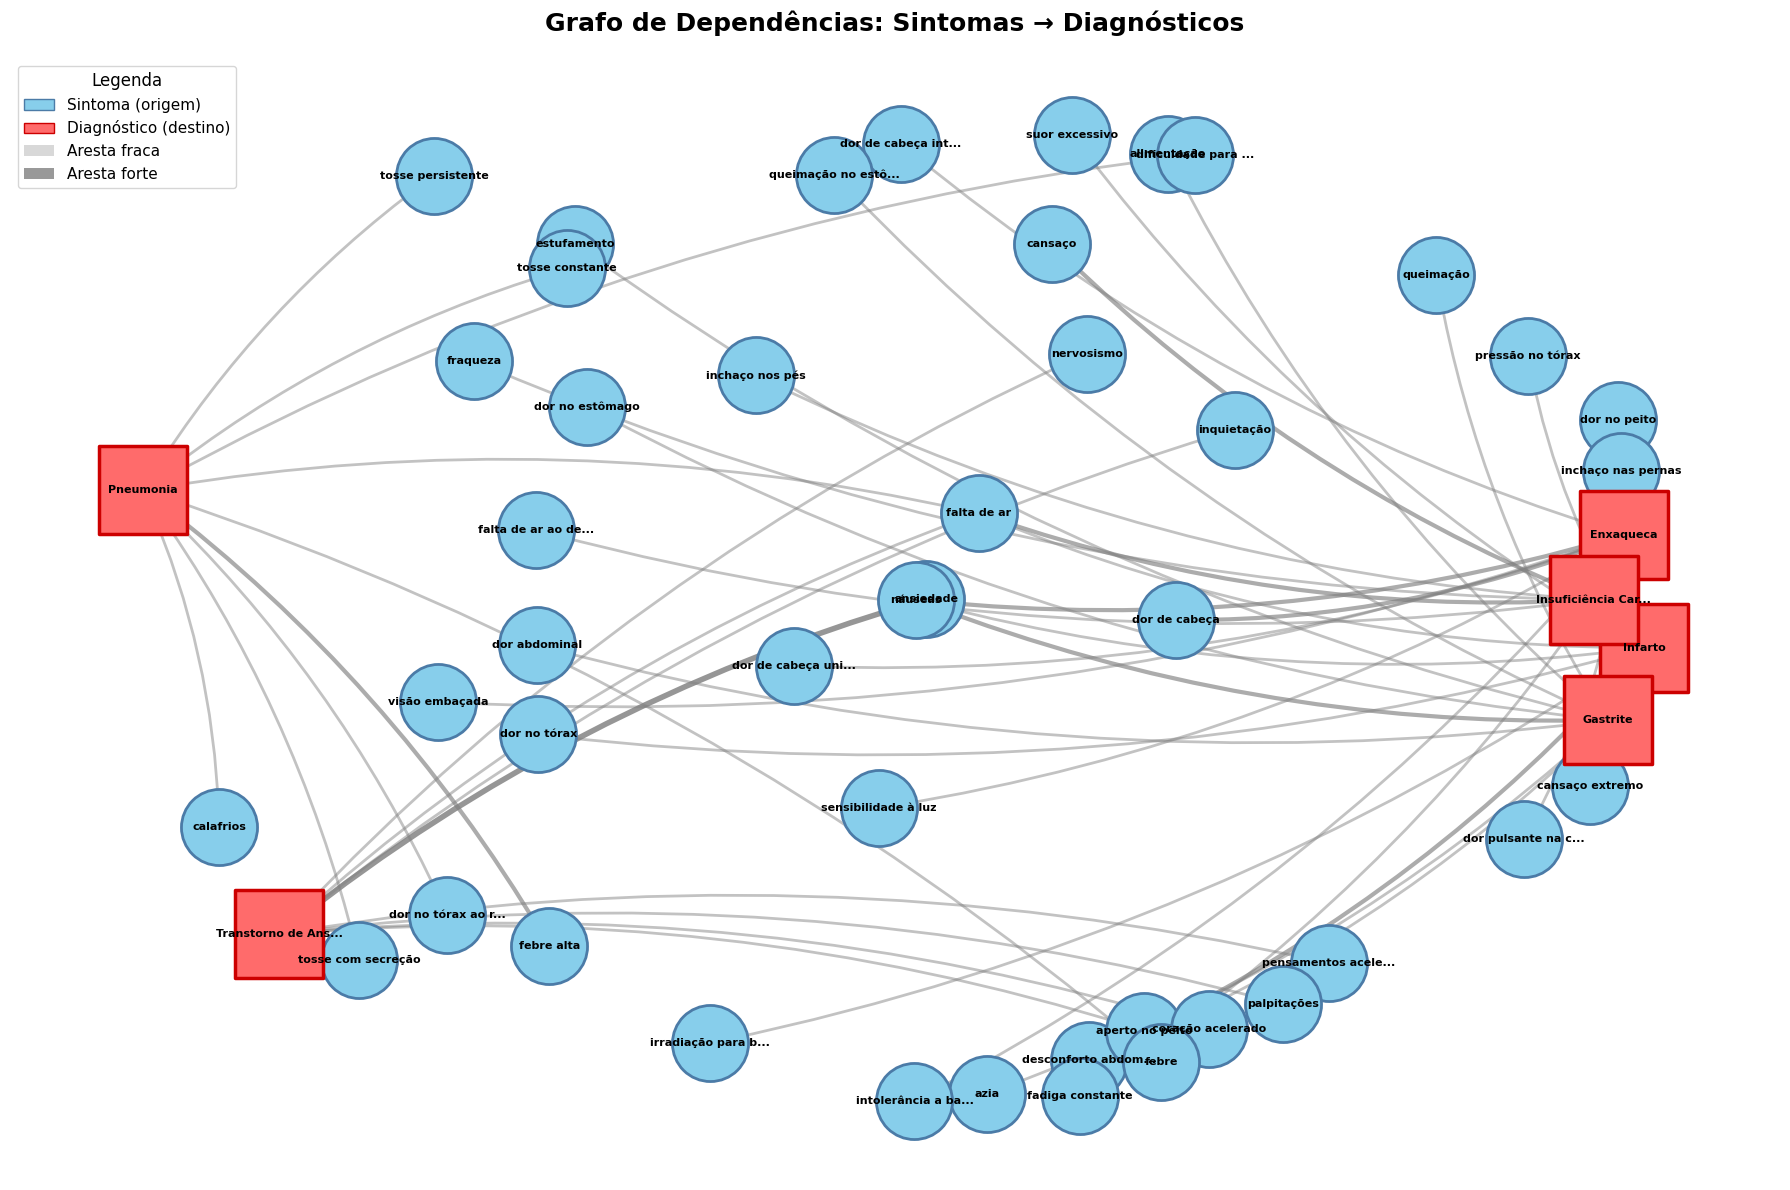

✓ Grafo de dependências visualizado com sucesso!


In [136]:
import subprocess
import sys

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib"])
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import FancyBboxPatch

# Usar layout hierarchical (Graphviz-inspired) com spring layout ajustado
pos = nx.spring_layout(G, k=2, iterations=100, seed=42)

# Separar nós por tipo
sintomas_nodes = [node for node, attr in G.nodes(data=True) if attr.get('tipo') == 'Sintoma']
diagnosticos_nodes = [node for node, attr in G.nodes(data=True) if attr.get('tipo') == 'Diagnóstico']

# Criar figura grande
fig, ax = plt.subplots(1, 1, figsize=(18, 12))
ax.set_title('Grafo de Dependências: Sintomas → Diagnósticos', fontsize=18, fontweight='bold', pad=20)

# Desenhar arestas com cores variadas por peso
edges = G.edges(data=True)
weights = [edge[2].get('weight', 1) for edge in edges]
max_weight = max(weights) if weights else 1

for (source, target, data) in edges:
    weight = data.get('weight', 1)
    alpha = min(0.3 + (weight / max_weight) * 0.7, 1.0)  # Transparência baseada no peso
    width = 1 + (weight / max_weight) * 4  # Largura da aresta baseada no peso
    
    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(source, target)],
        width=width,
        alpha=alpha,
        edge_color='gray',
        arrows=True,
        arrowsize=20,
        arrowstyle='-|>',
        connectionstyle='arc3,rad=0.1',
        ax=ax
    )

# Desenhar nós (Sintomas em azul)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=sintomas_nodes,
    node_color='#87CEEB',
    node_size=3000,
    node_shape='o',
    edgecolors='#4B7BA7',
    linewidths=2,
    ax=ax,
    label='Sintomas'
)

# Desenhar nós (Diagnósticos em vermelho)
nx.draw_networkx_nodes(
    G, pos,
    nodelist=diagnosticos_nodes,
    node_color='#FF6B6B',
    node_size=4000,
    node_shape='s',  # Quadrado para diagnósticos
    edgecolors='#CC0000',
    linewidths=2.5,
    ax=ax,
    label='Diagnósticos'
)

# Desenhar labels dos nós
labels = {}
for node in G.nodes():
    # Truncar labels longos
    if len(node) > 20:
        labels[node] = node[:17] + '...'
    else:
        labels[node] = node

nx.draw_networkx_labels(
    G, pos,
    labels,
    font_size=8,
    font_weight='bold',
    font_family='sans-serif',
    ax=ax
)

# Adicionar legenda
legend_elements = [
    mpatches.Patch(facecolor='#87CEEB', edgecolor='#4B7BA7', label='Sintoma (origem)'),
    mpatches.Patch(facecolor='#FF6B6B', edgecolor='#CC0000', label='Diagnóstico (destino)'),
    mpatches.Patch(facecolor='gray', alpha=0.3, label='Aresta fraca'),
    mpatches.Patch(facecolor='gray', alpha=0.8, label='Aresta forte')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, title='Legenda', title_fontsize=12)

# Configurações do plot
ax.axis('off')
fig.tight_layout()
plt.show()

print("✓ Grafo de dependências visualizado com sucesso!")

## Parte 4: Análise de Influência e Centralidade no Grafo

In [137]:
# Análise de Centralidade: Sintomas mais influentes e Diagnósticos mais associados

# 1. Grau de saída (out-degree) - Quantos diagnósticos cada sintoma pode levar
out_degree = dict(G.out_degree())
sintomas_influencia = {node: grau for node, grau in out_degree.items() if G.nodes[node]['tipo'] == 'Sintoma'}
sintomas_influencia_sorted = sorted(sintomas_influencia.items(), key=lambda x: x[1], reverse=True)

# 2. Grau de entrada (in-degree) - Quantos sintomas sugerem cada diagnóstico
in_degree = dict(G.in_degree())
diagnosticos_frequencia = {node: grau for node, grau in in_degree.items() if G.nodes[node]['tipo'] == 'Diagnóstico'}
diagnosticos_frequencia_sorted = sorted(diagnosticos_frequencia.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*100)
print("ANÁLISE DE INFLUÊNCIA NO GRAFO DE DEPENDÊNCIAS")
print("="*100)

print("\n🔴 SINTOMAS MAIS INFLUENTES (conectam a mais diagnósticos):")
for i, (sintoma, grau) in enumerate(sintomas_influencia_sorted[:10], 1):
    print(f"  {i:2d}. {sintoma:35s} → {grau} diagnósticos")

print("\n🟢 DIAGNÓSTICOS COM MAIOR FREQUÊNCIA DE SINTOMAS:")
for i, (diagnostico, grau) in enumerate(diagnosticos_frequencia_sorted[:10], 1):
    print(f"  {i:2d}. {diagnostico:35s} ← {grau} sintomas associados")

print("\n" + "="*100)


ANÁLISE DE INFLUÊNCIA NO GRAFO DE DEPENDÊNCIAS

🔴 SINTOMAS MAIS INFLUENTES (conectam a mais diagnósticos):
   1. falta de ar                         → 4 diagnósticos
   2. náuseas                             → 3 diagnósticos
   3. aperto no peito                     → 2 diagnósticos
   4. suor excessivo                      → 1 diagnósticos
   5. pressão no tórax                    → 1 diagnósticos
   6. tosse com secreção                  → 1 diagnósticos
   7. dor no estômago                     → 1 diagnósticos
   8. alimentação                         → 1 diagnósticos
   9. estufamento                         → 1 diagnósticos
  10. pensamentos acelerados              → 1 diagnósticos

🟢 DIAGNÓSTICOS COM MAIOR FREQUÊNCIA DE SINTOMAS:
   1. Pneumonia                           ← 9 sintomas associados
   2. Gastrite                            ← 9 sintomas associados
   3. Infarto                             ← 8 sintomas associados
   4. Enxaqueca                           ← 8 sintomas

## Parte 5: Visualizar Subgrafo - Sintomas Mais Influentes

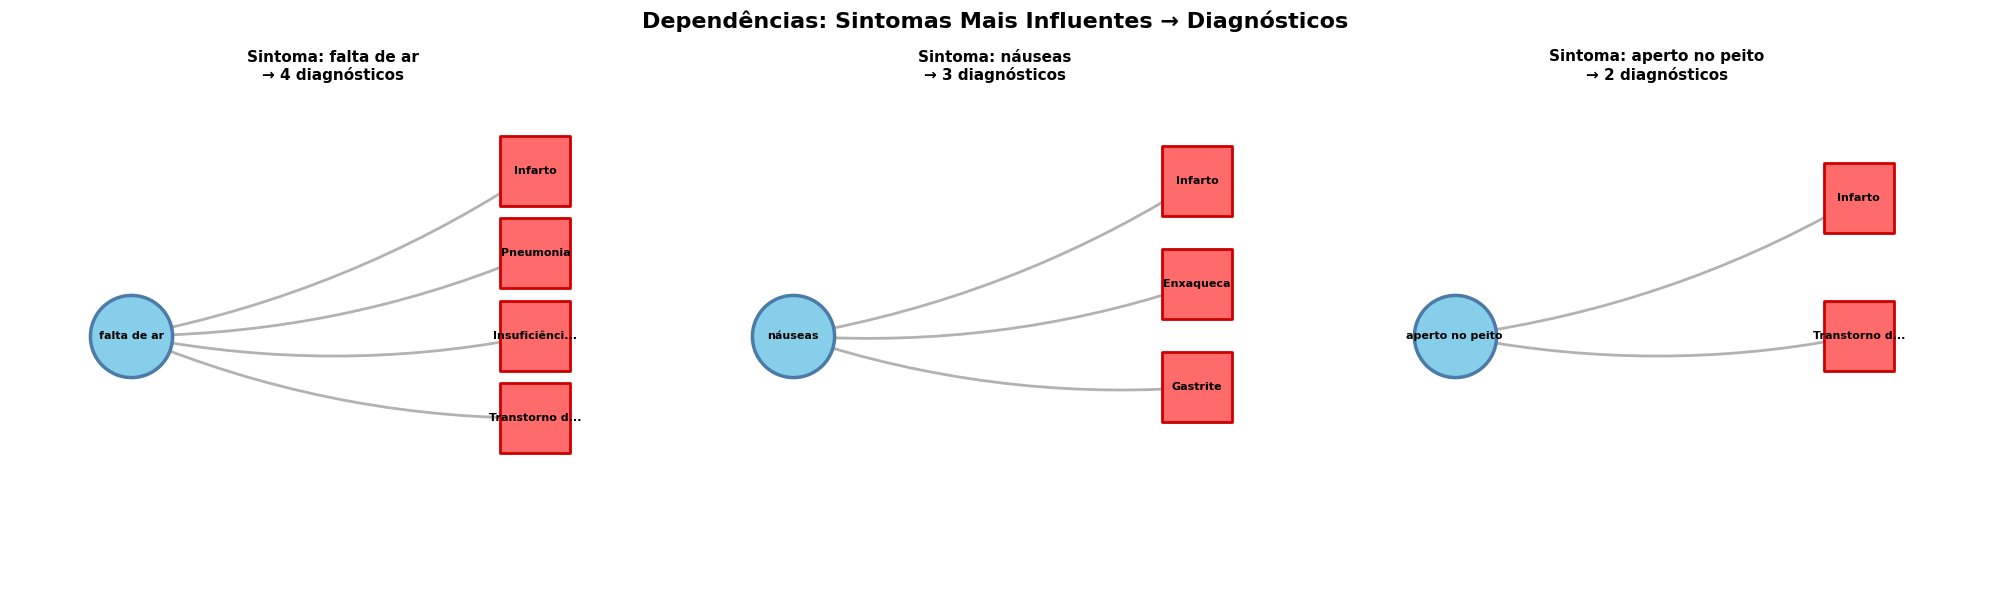

✓ Subgrafos dos sintomas mais influentes visualizados!


In [138]:
# Criar visualizações de subgrafos para sintomas influentes
sintomas_top = [s[0] for s in sintomas_influencia_sorted[:3]]  # Top 3 sintomas

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Dependências: Sintomas Mais Influentes → Diagnósticos', fontsize=16, fontweight='bold')

for idx, sintoma_selecionado in enumerate(sintomas_top):
    ax = axes[idx]
    
    # Criar subgrafo com o sintoma selecionado e seus vizinhos
    vizinhos = list(G.successors(sintoma_selecionado))  # Diagnósticos que este sintoma sugere
    nodes_subgrafo = [sintoma_selecionado] + vizinhos
    G_sub = G.subgraph(nodes_subgrafo).copy()
    
    # Layout hierárquico: sintoma na esquerda, diagnósticos na direita
    pos_sub = {}
    pos_sub[sintoma_selecionado] = (0, 0.5)
    
    for i, diagnostico in enumerate(vizinhos):
        y = 0.5 - (i - len(vizinhos)/2) * (1 / (len(vizinhos) + 1))
        pos_sub[diagnostico] = (1, y)
    
    # Desenhar arestas
    nx.draw_networkx_edges(G_sub, pos_sub, ax=ax, 
                          width=2, edge_color='gray', 
                          arrows=True, arrowsize=15,
                          arrowstyle='-|>', 
                          connectionstyle='arc3,rad=0.1',
                          alpha=0.6)
    
    # Desenhar nó do sintoma (azul, centro-esquerda)
    nx.draw_networkx_nodes(G_sub, pos_sub, 
                          nodelist=[sintoma_selecionado],
                          node_color='#87CEEB',
                          node_size=3500,
                          node_shape='o',
                          edgecolors='#4B7BA7',
                          linewidths=2.5,
                          ax=ax)
    
    # Desenhar nós dos diagnósticos (vermelho, direita)
    nx.draw_networkx_nodes(G_sub, pos_sub,
                          nodelist=vizinhos,
                          node_color='#FF6B6B',
                          node_size=2500,
                          node_shape='s',
                          edgecolors='#CC0000',
                          linewidths=2,
                          ax=ax)
    
    # Labels
    labels_sub = {}
    for node in nodes_subgrafo:
        if len(node) > 15:
            labels_sub[node] = node[:12] + '...'
        else:
            labels_sub[node] = node
    
    nx.draw_networkx_labels(G_sub, pos_sub, labels_sub,
                           font_size=8, font_weight='bold', ax=ax)
    
    # Título e configurações
    ax.set_title(f'Sintoma: {sintoma_selecionado}\n→ {len(vizinhos)} diagnósticos', 
                fontsize=11, fontweight='bold')
    ax.axis('off')
    ax.set_xlim(-0.3, 1.3)
    ax.set_ylim(-0.1, 1.1)

fig.tight_layout()
plt.show()

print("✓ Subgrafos dos sintomas mais influentes visualizados!")

## Parte 6: Estatísticas Estruturais do Grafo

In [139]:
# Análise de Estrutura do Grafo
print("\n" + "="*100)
print("ESTATÍSTICAS ESTRUTURAIS DO GRAFO DE DEPENDÊNCIAS")
print("="*100)

print(f"\n📊 TOPOLOGIA:")
print(f"  Total de nós: {G.number_of_nodes()}")
print(f"  Total de arestas: {G.number_of_edges()}")
print(f"  Nós sintomas: {len(sintomas_nodes)}")
print(f"  Nós diagnósticos: {len(diagnosticos_nodes)}")
print(f"  Densidade do grafo: {nx.density(G):.4f}")
print(f"  É conexo? {nx.is_weakly_connected(G)}")

# Distribuição de graus
print(f"\n🔗 CONECTIVIDADE (Out-Degree dos Sintomas):")
out_degrees = [G.out_degree(node) for node in sintomas_nodes]
print(f"  Mínimo: {min(out_degrees)} diagnósticos")
print(f"  Máximo: {max(out_degrees)} diagnósticos")
print(f"  Média: {sum(out_degrees)/len(out_degrees):.2f} diagnósticos")

print(f"\n🎯 CONECTIVIDADE (In-Degree dos Diagnósticos):")
in_degrees = [G.in_degree(node) for node in diagnosticos_nodes]
print(f"  Mínimo: {min(in_degrees)} sintomas")
print(f"  Máximo: {max(in_degrees)} sintomas")
print(f"  Média: {sum(in_degrees)/len(in_degrees):.2f} sintomas")

# Caminhos e componentes
print(f"\n🌳 ESTRUTURA DE CAMINHOS:")
print(f"  Número de componentes fracamente conectados: {nx.number_weakly_connected_components(G)}")
try:
    diametro = nx.diameter(G.to_undirected())
    print(f"  Diâmetro do grafo: {diametro}")
except:
    print(f"  Diâmetro: N/A (grafo não é conexo)")

# Peso total das arestas
total_weight = sum(data['weight'] for _, _, data in G.edges(data=True))
print(f"\n⚖️  PESO DAS RELAÇÕES:")
print(f"  Peso total de todas as arestas: {total_weight}")
print(f"  Peso médio por aresta: {total_weight/G.number_of_edges():.2f}")

print("\n" + "="*100)


ESTATÍSTICAS ESTRUTURAIS DO GRAFO DE DEPENDÊNCIAS

📊 TOPOLOGIA:
  Total de nós: 50
  Total de arestas: 50
  Nós sintomas: 44
  Nós diagnósticos: 6
  Densidade do grafo: 0.0204
  É conexo? True

🔗 CONECTIVIDADE (Out-Degree dos Sintomas):
  Mínimo: 1 diagnósticos
  Máximo: 4 diagnósticos
  Média: 1.14 diagnósticos

🎯 CONECTIVIDADE (In-Degree dos Diagnósticos):
  Mínimo: 8 sintomas
  Máximo: 9 sintomas
  Média: 8.33 sintomas

🌳 ESTRUTURA DE CAMINHOS:
  Número de componentes fracamente conectados: 1
  Diâmetro do grafo: 6

⚖️  PESO DAS RELAÇÕES:
  Peso total de todas as arestas: 62
  Peso médio por aresta: 1.24



## Conclusão e Artefatos Gerados

### 📦 Arquivos Gerados:

1. **diagnosticos_ontologia.owl** (17 KB)
   - Formato: RDF/XML (padrão OWL)
   - Localização: `/document/diagnosticos_ontologia.owl`
   - Conteúdo: 157 triplas RDF formalizando as relações sintoma-diagnóstico
   - Uso: Importável em ferramentas de ontologia (Protégé, etc.)

2. **resultados_diagnostico.csv** (5.5 KB)
   - Saída do sistema de processamento NLP
   - Contém as análises de 30 frases com diagnósticos sugeridos

### 🎯 Aplicações Práticas:

O arquivo OWL pode ser utilizado para:
- Integração com sistemas de informação biomédica
- Consultas usando SPARQL
- Validação de inconsistências ontológicas
- Reutilização em ferramentas de reasoning
- Documentação formal do conhecimento do domínio

### Parte 7: Exportar Ontologia em Formato OWL

In [140]:
# Exportar Ontologia em Formato OWL (RDF/XML)
from pathlib import Path
from config import DOCUMENTS_DIR, ONTOLOGY_OWL

# Criar diretório se não existir
DOCUMENTS_DIR.mkdir(parents=True, exist_ok=True)

# Serializar a ontologia em formato RDF/XML (padrão OWL)
ontologia.serialize(destination=str(ONTOLOGY_OWL), format='xml')

print(f"✅ Ontologia exportada com sucesso!")
print(f"📁 Arquivo: {ONTOLOGY_OWL}")
print(f"📊 Tamanho: {ONTOLOGY_OWL.stat().st_size / 1024:.2f} KB")
print(f"📝 Triplas RDF: {len(ontologia)}")

# Exibir primeiras linhas do arquivo para validação
print("\n🔍 Preview do arquivo OWL (primeiras linhas):")
with open(ONTOLOGY_OWL, 'r', encoding='utf-8') as f:
    linhas = f.readlines()[:15]
    print(''.join(linhas))
    if len(linhas) < len(open(ONTOLOGY_OWL).readlines()):
        print(f"... ({len(open(ONTOLOGY_OWL).readlines())} linhas no total)")

✅ Ontologia exportada com sucesso!
📁 Arquivo: /Users/amanda/Documents/FIAP/projetos/chap01-phase02-automate-diagnostics/document/diagnosticos_ontologia.owl
📊 Tamanho: 17.19 KB
📝 Triplas RDF: 157

🔍 Preview do arquivo OWL (primeiras linhas):
<?xml version="1.0" encoding="utf-8"?>
<rdf:RDF
   xmlns:diag="http://example.com/diagnosis/ontology/"
   xmlns:rdf="http://www.w3.org/1999/02/22-rdf-syntax-ns#"
>
  <rdf:Description rdf:about="http://example.com/diagnosis/ontology/dor_de_cabeça_intensa">
    <rdf:type rdf:resource="http://example.com/diagnosis/ontology/Sintoma"/>
    <diag:descricao>dor de cabeça intensa</diag:descricao>
    <diag:sugere rdf:resource="http://example.com/diagnosis/ontology/Enxaqueca"/>
  </rdf:Description>
  <rdf:Description rdf:about="http://example.com/diagnosis/ontology/dor_no_peito">
    <rdf:type rdf:resource="http://example.com/diagnosis/ontology/Sintoma"/>
    <diag:descricao>dor no peito</diag:descricao>
    <diag:sugere rdf:resource="http://example.com/diag